In [73]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [74]:
import torch
import numpy as np
from model import WaveFunctionNN, train, predicted
from prepare_data import get_dataloader_from_csv_file, extract_t_and_y_from_loader
from draw_with_plot import plot_data_and_predicted, draw_t_distribution
import pandas as pd

In [75]:
SEED = 42
BATCH_SIZE = 100
HIDDEN_SIZE = 512
NUM_LAYERS = 6
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
EPOCHS = 500

LR = 0.00001

torch.manual_seed(42)
print(f"device: {DEVICE}")

device: cuda


In [ ]:
train_loader, eval_loader, scaler = get_dataloader_from_csv_file('finance_smoothed.csv', ['t'], ['y'], BATCH_SIZE)

model = WaveFunctionNN(HIDDEN_SIZE, NUM_LAYERS)

best_loss = train(model, train_loader, eval_loader, EPOCHS, LR, DEVICE, eval_method='grid')


Starting training on cuda for 500 epochs...
Gradient clipping enabled with max norm = 5.0
Epoch 1: New best composite score: 25.835562 → Model saved!
Epoch [1/500] | Train Loss: 5.661549 | Schrodinger: 0.020941 | Obs: 4.904164 | Norm: 0.736444 | Grad Norm: 86.8427 | Eval MAE: 4.985489 | Composite: 25.835562 | LR: 0.000010
Epoch 6: New best composite score: 25.756429 → Model saved!
Epoch [6/500] | Train Loss: 5.080724 | Schrodinger: 0.005559 | Obs: 4.390816 | Norm: 0.684349 | Grad Norm: 14.6379 | Eval MAE: 5.000733 | Composite: 25.756429 | LR: 0.000010
Epoch 36: New best composite score: 25.489139 → Model saved!
Epoch [36/500] | Train Loss: 4.867992 | Schrodinger: 0.004527 | Obs: 4.079301 | Norm: 0.784163 | Grad Norm: 940.9954 | Eval MAE: 5.000733 | Composite: 25.489139 | LR: 0.000010
Epoch 40: New best composite score: 25.306302 → Model saved!
Epoch [40/500] | Train Loss: 4.847429 | Schrodinger: 0.004942 | Obs: 4.301014 | Norm: 0.541473 | Grad Norm: 744.6057 | Eval MAE: 5.000733 | Comp

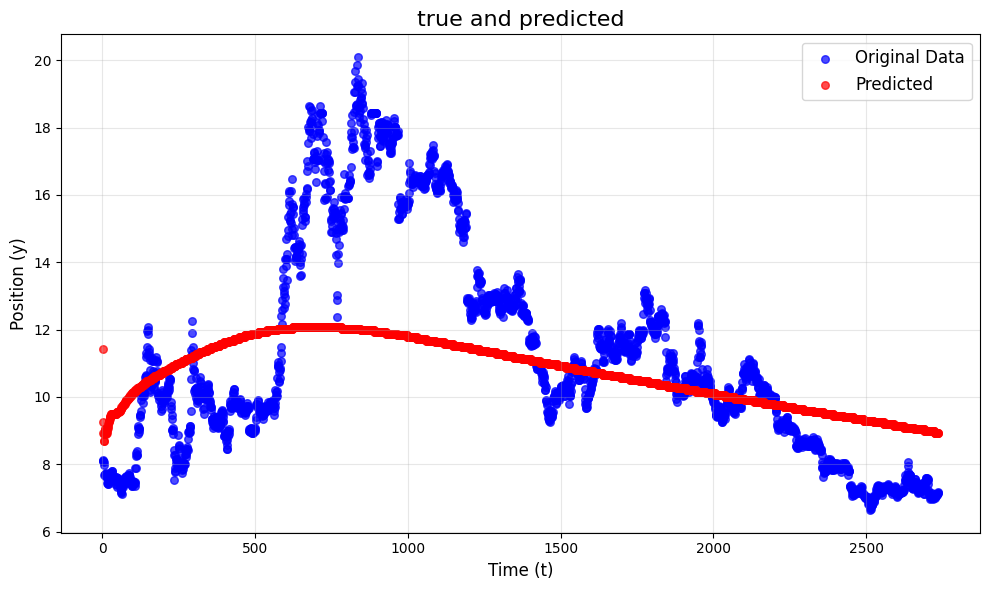

In [77]:
model.load_state_dict(torch.load('models_pth/best_model.pth'))

t, original_x = extract_t_and_y_from_loader(train_loader)

predicted_t = torch.tensor(t.reshape(-1, 1)).to(DEVICE)
predicted_x = predicted(model, predicted_t, DEVICE)

predicted_t = predicted_t.cpu().numpy()
predicted_x = scaler.inverse_transform(predicted_x.cpu().numpy())

original_x = scaler.inverse_transform(original_x.reshape(-1, 1))

predicted_data = pd.DataFrame({'t': predicted_t.reshape(-1), 'y': predicted_x.reshape(-1)})
original_data = pd.DataFrame({'t': t.reshape(-1), 'y': original_x.reshape(-1)})

plot_data_and_predicted("true and predicted", original_data, predicted_data)

torch.Size([1000, 1]) torch.Size([1000, 1])


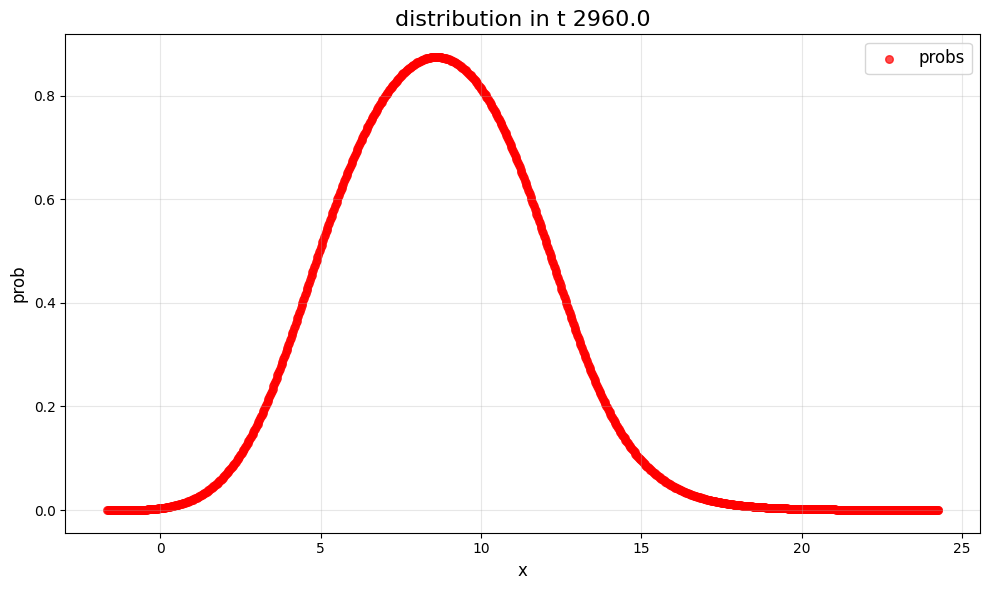

In [78]:
draw_t_distribution(model,2960,scaler, DEVICE)

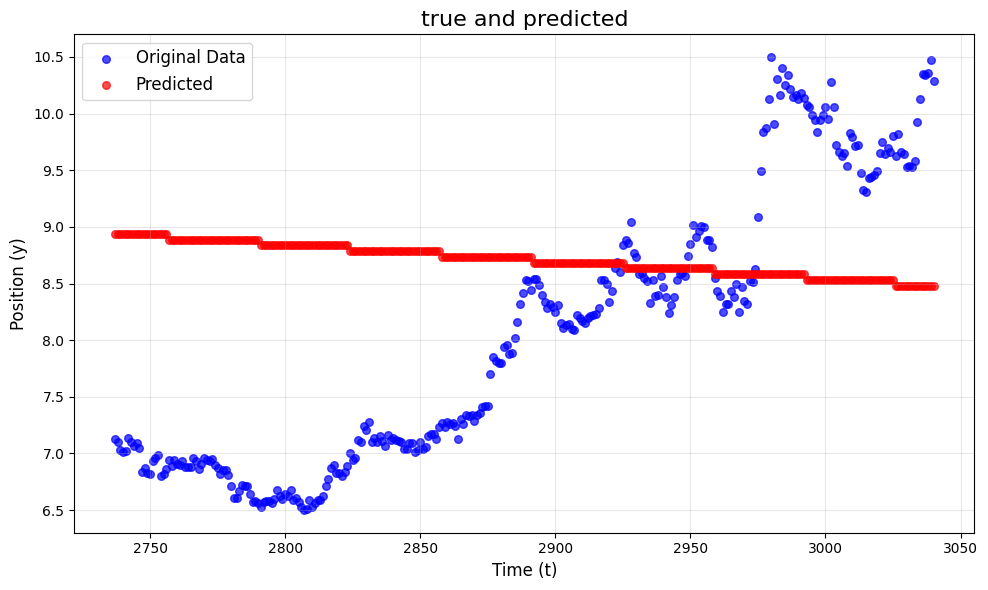

In [79]:
model.load_state_dict(torch.load('models_pth/best_model.pth'))

t, original_x = extract_t_and_y_from_loader(eval_loader)

predicted_t = torch.tensor(t.reshape(-1, 1)).to(DEVICE)
predicted_x = predicted(model, predicted_t, DEVICE)

predicted_t = predicted_t.cpu().numpy()
predicted_x = scaler.inverse_transform(predicted_x.cpu().numpy())

original_x = scaler.inverse_transform(original_x.reshape(-1, 1))

predicted_data = pd.DataFrame({'t': predicted_t.reshape(-1), 'y': predicted_x.reshape(-1)})
original_data = pd.DataFrame({'t': t.reshape(-1), 'y': original_x.reshape(-1)})

plot_data_and_predicted("true and predicted", original_data, predicted_data)

In [80]:
predicted_data.to_csv('predicted_with_schrodinger.csv', index=False)